In [48]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.io import wavfile
from scipy.signal.windows import tukey
from pathlib import Path

In [ ]:
def window_organ_signal(signal, sample_rate, start_sec, end_sec, fade_fraction=0.1):
    """
    Ritaglia il segnale e applica una finestra di Tukey per evitare click e leakage.
    
    :param signal: Array numpy del segnale audio.
    :param sample_rate: Frequenza di campionamento (es. 44100).
    :param start_sec: Secondo di inizio del taglio.
    :param end_sec: Secondo di fine del taglio.
    :param fade_fraction: Percentuale della finestra dedicata al fade (0-1).
    :return: Segnale ritagliato e finestrato.
    
    """
    # 1. Ritaglio temporale
    start_sample = int(start_sec * sample_rate)
    end_sample = int(end_sec * sample_rate)
    trimmed_signal = signal[start_sample:end_sample]
    
    # 2. Creazione della finestra di Tukey
    # fade_fraction definisce quanto i bordi sono smussati.
    # Se 0 è una rettangolare, se 1 è una finestra di Hann.
    win = tukey(len(trimmed_signal), alpha=fade_fraction)
    
    # 3. Applicazione
    windowed_signal = trimmed_signal * win
    
    return windowed_signal

In [ ]:
def process_organ_notes(folder_path, start_sec=0.5, end_sec=2.5):
    data_dir = Path(folder_path)
    files = sorted(data_dir.glob('note_*.wav'))
    results = {}

    for file_path in files:
        samplerate, data = wavfile.read(file_path)
        
        # 1. Normalizzazione e gestione Stereo -> Mono
        if data.dtype == np.int16:
            data = data / 32768.0
            
        if len(data.shape) > 1:
            signal = np.mean(data, axis=1)
        else:
            signal = data

        # 2. CHIAMATA ALLA FUNZIONE ESTERNA
        # Usiamo la funzione che abbiamo scritto prima!
        final_signal = window_organ_signal(signal, samplerate, start_sec, end_sec)
        
        # 3. FFT e Analisi
        n = len(final_signal)
        fft_values = np.fft.fft(final_signal)
        frequencies = np.fft.fftfreq(n, d=1/samplerate)[:n//2]
        power_spectrum = np.abs(fft_values[:n//2])**2
        
        results[file_path.name] = {
            'freq': frequencies,
            'psd': power_spectrum,
            'rate': samplerate
        }
        print(f"Elaborato: {file_path.name}")

    return results

/var/folders/xt/7jwm3jpn57sgpkrqpy1g1bph0000gn/T/ipykernel_26814/3539811343.py:3: WavFileWarning: Chunk (non-data) not understood, skipping it.
  samplerate, data = wavfile.read(file_path)


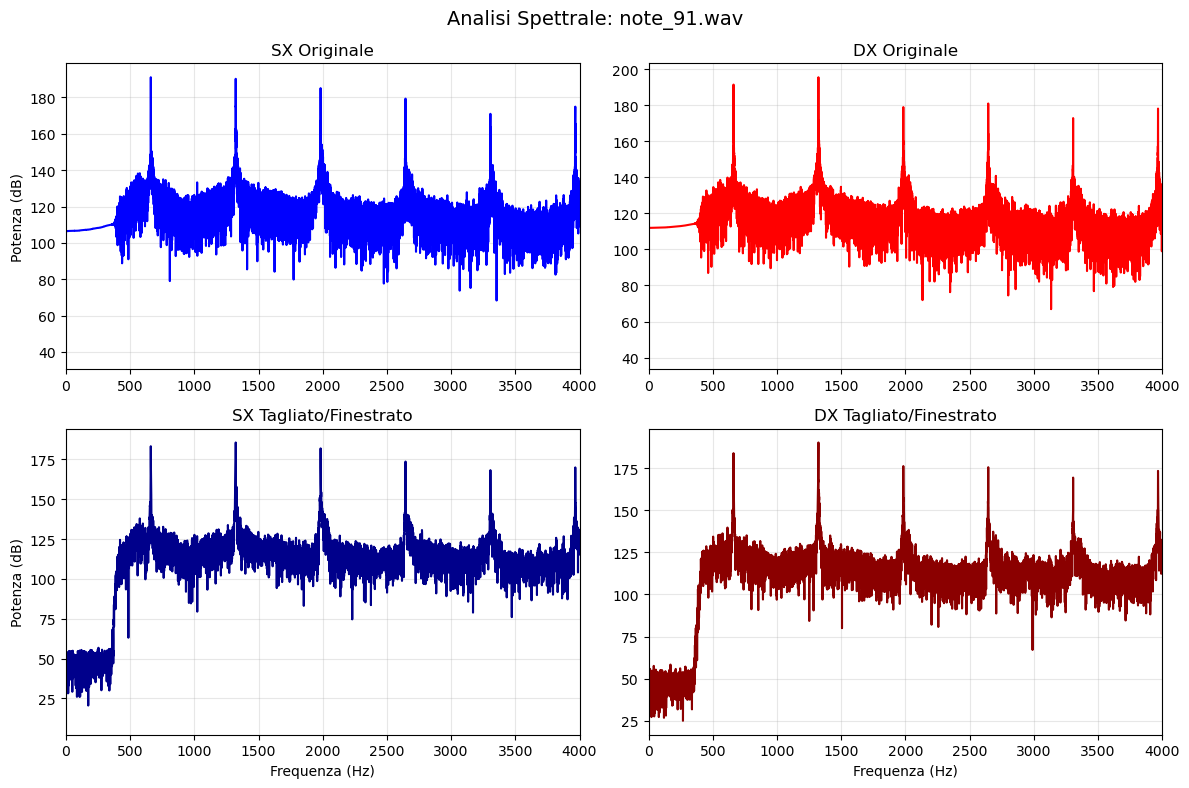

In [56]:
def confronta_spettri_nota(file_path, start_s=0.5, end_s=2.5):
    # 1. Caricamento "manuale"
    samplerate, data = wavfile.read(file_path)
    
    # Conversione float (per evitare overflow e gestire bene i calcoli)
    if data.dtype == np.int16:
        data = data / 32768.0

    # Separazione canali
    sig_sx_orig = data[:, 0]
    sig_dx_orig = data[:, 1]
    
    # 2. Otteniamo i segnali tagliati usando la tua funzione
    # (Assumendo che window_organ_signal sia definita nel tuo script)
    sig_sx_cut = window_organ_signal(sig_sx_orig, samplerate, start_s, end_s)
    sig_dx_cut = window_organ_signal(sig_dx_orig, samplerate, start_s, end_s)

    # 3. Definiamo noi la logica della FFT e Power Spectrum
    # Invece di usare funzioni pronte, facciamo i passaggi base
    def calcola_psd_base(segno, fs):
        N = len(segno)
        # Trasformata di Fourier
        fft_complex = np.fft.fft(segno)
        # Prendiamo solo la prima metà (simmetria)
        metà = N // 2
        # Modulo al quadrato (Power) e normalizzazione base per la lunghezza
        psd = (np.abs(fft_complex[:metà])**2) / N
        # Vettore frequenze: k * fs / N
        freqs = np.array([k * fs / N for k in range(metà)])
        return freqs, psd

    # Calcoliamo i 4 spettri
    f_orig, psd_sx_orig = calcola_psd_base(sig_sx_orig, samplerate)
    _,      psd_dx_orig = calcola_psd_base(sig_dx_orig, samplerate)
    f_cut,  psd_sx_cut  = calcola_psd_base(sig_sx_cut, samplerate)
    _,      psd_dx_cut  = calcola_psd_base(sig_dx_cut, samplerate)

    # 4. Creazione dei 4 subplots
    fig, axs = plt.subplots(2, 2, figsize=(12, 8))
    fig.suptitle(f"Analisi Spettrale: {Path(file_path).name}", fontsize=14)

    # Definiamo una lista di dati per iterare facilmente sui grafici
    dati_plot = [
        (f_orig, psd_sx_orig, "SX Originale", "blue"),
        (f_orig, psd_dx_orig, "DX Originale", "red"),
        (f_cut,  psd_sx_cut,  "SX Tagliato/Finestrato", "darkblue"),
        (f_cut,  psd_dx_cut,  "DX Tagliato/Finestrato", "darkred")
    ]

    for i, (f, p, titolo, colore) in enumerate(dati_plot):
        ax = axs[i//2, i%2]
        # Usiamo il logaritmo per vedere meglio le armoniche (decibel relativi)
        ax.plot(f, 10 * np.log10(p + 1e-12), color=colore) 
        ax.set_title(titolo)
        ax.set_xlim(0, 4000) # L'organo raramente ha armoniche utili sopra i 4kHz
        ax.grid(True, alpha=0.3)
        if i >= 2: ax.set_xlabel("Frequenza (Hz)")
        if i % 2 == 0: ax.set_ylabel("Potenza (dB)")

    plt.tight_layout()
    plt.show()


confronta_spettri_nota('data/note_91.wav')